# 🐄 Cow Weight Prediction — Non-linear Regression Evaluation

**Step 1 Improvements:** Outlier Cleaning (A1) · Feature Engineering (A2) · Log-Weight Transform (A3)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

%matplotlib inline
print("Libraries imported successfully.")

c:\Users\bimyu\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Libraries imported successfully.


In [2]:
import scipy.stats as stats

# Load calibrated dataset
csv_path = r"datasets/features_updated.csv"
if not os.path.exists(csv_path):
    csv_path = r"datasets\features_updated.csv"

print(f"Loading dataset from: {csv_path}")
df_raw = pd.read_csv(csv_path, sep=';')
print(f"Raw dataset: {len(df_raw)} rows")

# === A1. Outlier Cleaning ===
feat_cols = ['BL_yolov8l', 'WH_yolov8l', 'CG_yolov8l']
df_base = df_raw[['weight_kg', 'scale_factor_back'] + feat_cols].dropna().copy()

# 1. Remove physically impossible CG values (real cow girth: 120-280 cm)
mask_cg = df_base['CG_yolov8l'] <= 300
n_bad_cg = (~mask_cg).sum()

# 2. Remove failed sticker detections (z-score > 3 on scale_factor_back)
z_sfb = np.abs(stats.zscore(df_base['scale_factor_back']))
mask_sfb = z_sfb <= 3
n_bad_sfb = (~mask_sfb).sum()

# 3. Remove truncated/partial cow images (BL too short)
mask_bl = df_base['BL_yolov8l'] >= 60
n_bad_bl = (~mask_bl).sum()

df_clean = df_base[mask_cg & mask_sfb & mask_bl][['weight_kg'] + feat_cols].copy()

print(f"\n=== A1. OUTLIER REMOVAL REPORT ===")
print(f"  CG > 300 cm removed       : {n_bad_cg} samples")
print(f"  scale_factor_back z>3 rem : {n_bad_sfb} samples")
print(f"  BL < 60 cm removed        : {n_bad_bl} samples")
print(f"  --- Remaining samples     : {len(df_clean)} / {len(df_base)}")
print(f"  --- Discarded             : {len(df_base) - len(df_clean)} samples")
print()

# Quick correlation check after cleaning
print("Feature-Weight Pearson r (after cleaning):")
for col in feat_cols:
    r, p = stats.pearsonr(df_clean[col], df_clean['weight_kg'])
    print(f"  {col}: r={r:.4f}, p={p:.4f}")


Loading dataset from: ../datasets/acme_ai/tests/feature_extraction_result/features_updated.csv
Raw dataset: 509 rows

=== A1. OUTLIER REMOVAL REPORT ===
  CG > 300 cm removed       : 8 samples
  scale_factor_back z>3 rem : 6 samples
  BL < 60 cm removed        : 2 samples
  --- Remaining samples     : 498 / 509
  --- Discarded             : 11 samples

Feature-Weight Pearson r (after cleaning):
  BL_yolov8l: r=0.5522, p=0.0000
  WH_yolov8l: r=0.2877, p=0.0000
  CG_yolov8l: r=0.4224, p=0.0000


In [10]:
# === A2. Engineered Features ===
# Original 3 features
BL = df_clean['BL_yolov8l']
WH = df_clean['WH_yolov8l']
CG = df_clean['CG_yolov8l']

# Derived biological features
df_clean = df_clean.copy()
df_clean['BL_WH']       = BL * WH               # Body footprint area
df_clean['BL_sq']       = BL ** 2               # Allometric BL² scaling
df_clean['WH_BL_ratio'] = WH / BL               # Body proportionality
df_clean['CG_sq']       = CG ** 2               # Girth² (weight tape formula basis)
df_clean['vol_proxy']   = BL * (CG ** 2)        # Barrel volume proxy
df_clean['log_vol']     = np.log(BL * (CG ** 2)) # Log-linearized volume

# --- Correlation analysis of all features ---
all_feat_cols = feat_cols + ['BL_WH','BL_sq','WH_BL_ratio','CG_sq','vol_proxy','log_vol']
print("=== A2. FEATURE-WEIGHT CORRELATIONS (after cleaning) ===")
corr_data = []
for col in all_feat_cols:
    r, p = stats.pearsonr(df_clean[col], df_clean['weight_kg'])
    corr_data.append({
    'Feature': col, 
    'Pearson r': round(r, 4), 
    'p-value': f'{p:.2e}' if p < 0.0001 else f'{p:.4f}'
})
df_corr = pd.DataFrame(corr_data).sort_values('Pearson r', key=abs, ascending=False)
print(df_corr.to_string(index=False))

# Feature sets for model training
feat_base      = ['BL_yolov8l', 'WH_yolov8l', 'CG_yolov8l']
feat_engineered = feat_base + ['BL_WH', 'BL_sq', 'WH_BL_ratio', 'CG_sq', 'vol_proxy', 'log_vol']
feat_volumetric = ['vol_proxy']
y_linear = df_clean['weight_kg']
y_log    = np.log(df_clean['weight_kg'])   # Log-transform of target (A3)

X_base       = df_clean[feat_base]
X_engineered = df_clean[feat_engineered]
X_volumetric = df_clean[feat_volumetric]
print(f"\nTraining set: {len(df_clean)} samples, {len(feat_engineered)} engineered features")


=== A2. FEATURE-WEIGHT CORRELATIONS (after cleaning) ===
    Feature  Pearson r  p-value
      BL_sq     0.5577 4.84e-42
 BL_yolov8l     0.5522 4.39e-41
    log_vol     0.5174 1.91e-35
  vol_proxy     0.5122 1.16e-34
      BL_WH     0.4760 1.59e-29
 CG_yolov8l     0.4224 5.76e-23
      CG_sq     0.4109 1.04e-21
 WH_yolov8l     0.2877 6.04e-11
WH_BL_ratio    -0.2435 3.71e-08

Training set: 498 samples, 9 engineered features


In [4]:
# Helper function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0

# Generic evaluator function
def evaluate_regression_model(name, regressor, X, y, scale=False):
    # Split train/test (80/20)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Apply Standard Scaling if requested (important for SVR)
    if scale:
        pipeline = make_pipeline(StandardScaler(), regressor)
    else:
        pipeline = make_pipeline(regressor)
        
    # Train model
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    # Metrics
    metrics = {
        'model_name': name,
        'train': {
            'r2': r2_score(y_train, y_train_pred),
            'mae': mean_absolute_error(y_train, y_train_pred),
            'rmse': root_mean_squared_error(y_train, y_train_pred),
            'mape': mean_absolute_percentage_error(y_train, y_train_pred)
        },
        'test': {
            'r2': r2_score(y_test, y_test_pred),
            'mae': mean_absolute_error(y_test, y_test_pred),
            'rmse': root_mean_squared_error(y_test, y_test_pred),
            'mape': mean_absolute_percentage_error(y_test, y_test_pred)
        }
    }
    
    # 5-Fold Cross-Validation on the full set
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
    cv_mae_scores = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
    
    metrics['cv'] = {
        'r2_mean': np.mean(cv_r2_scores),
        'r2_std': np.std(cv_r2_scores),
        'mae_mean': -np.mean(cv_mae_scores)
    }
    
    return metrics

In [5]:
# Extend evaluate_regression_model to support log-space target
# (pass y_log as y, set log_target=True to back-transform for metrics)

def evaluate_model_full(name, regressor, X, y, scale=False, log_target=False):
    """
    Evaluate a regression model with train/test split + 5-fold CV.
    If log_target=True, y is assumed to be log(weight) and predictions
    are back-transformed via exp() before computing MAE/MAPE.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    if scale:
        pipeline = make_pipeline(StandardScaler(), regressor)
    else:
        pipeline = make_pipeline(regressor)
    
    pipeline.fit(X_train, y_train)
    y_tr_pred = pipeline.predict(X_train)
    y_te_pred = pipeline.predict(X_test)
    
    # Back-transform if log target
    if log_target:
        y_train_orig = np.exp(y_train)
        y_test_orig  = np.exp(y_test)
        y_tr_orig    = np.exp(y_tr_pred)
        y_te_orig    = np.exp(y_te_pred)
    else:
        y_train_orig, y_test_orig = y_train, y_test
        y_tr_orig, y_te_orig     = y_tr_pred, y_te_pred
    
    # Cross-validation (always in target space, so scoring uses consistent metric)
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2  = cross_val_score(pipeline, X, y, cv=kf, scoring='r2')
    cv_mae = cross_val_score(pipeline, X, y, cv=kf, scoring='neg_mean_absolute_error')
    cv_mae_mean = -np.mean(cv_mae)
    if log_target:
        # Approximate back-transformed CV MAE (not exact but informative)
        cv_mae_mean = cv_mae_mean * np.mean(np.exp(y))   # rough scale-back
    
    return {
        'model_name': name,
        'train': {
            'r2':   r2_score(y_train_orig, y_tr_orig),
            'mae':  mean_absolute_error(y_train_orig, y_tr_orig),
            'mape': mean_absolute_percentage_error(y_train_orig, y_tr_orig)
        },
        'test': {
            'r2':   r2_score(y_test_orig, y_te_orig),
            'mae':  mean_absolute_error(y_test_orig, y_te_orig),
            'mape': mean_absolute_percentage_error(y_test_orig, y_te_orig)
        },
        'cv': {
            'r2_mean':  np.mean(cv_r2),
            'r2_std':   np.std(cv_r2),
            'mae_mean': cv_mae_mean
        }
    }

print("Extended evaluator ready.")


Extended evaluator ready.


In [6]:
# === A3. Train all models across 3 scenarios ===
# Scenario A: Cleaned + Base features (BL, WH, CG) — linear target
# Scenario B: Cleaned + Engineered features           — linear target
# Scenario C: Cleaned + Engineered features           — LOG target (A3)

MODELS = [
    ("Linear Baseline",      LinearRegression(),                                          False),
    ("Polynomial (Deg 2)",   make_pipeline(PolynomialFeatures(degree=2), LinearRegression()), False),
    ("SVR (RBF Kernel)",     SVR(C=10.0, epsilon=0.1),                                   True),
    ("Random Forest",        RandomForestRegressor(n_estimators=150, max_depth=5,
                                                   min_samples_split=6, random_state=42), False),
    ("Gradient Boosting",    GradientBoostingRegressor(n_estimators=100, learning_rate=0.05,
                                                       max_depth=3, random_state=42),     False),
    ("Volumetric (BL*CG²)", LinearRegression(),                                          False),
]

def run_scenario(label, X, y, log_target=False, volumetric=False):
    print(f"\n{'='*55}")
    print(f"  SCENARIO: {label}")
    print(f"{'='*55}")
    results = []
    for name, model, scale in MODELS:
        X_use = X_volumetric if "Volumetric" in name else X
        if "SVR" in name and log_target:
            model_use = SVR(C=0.1, epsilon=0.05)
        else:
            model_use = model
        r = evaluate_model_full(name, model_use, X_use, y, scale=scale, log_target=log_target)
        results.append(r)
        print(f"  [{name:30s}]  Test R²={r['test']['r2']:.4f}  MAE={r['test']['mae']:.1f}kg")
    return results

res_A = run_scenario("A: Cleaned + Base Features",       X_base,       y_linear)
res_B = run_scenario("B: Cleaned + Engineered Features", X_engineered, y_linear)
res_C = run_scenario("C: Engineered + Log(Weight) [A3]", X_engineered, y_log, log_target=True)

print("\nAll scenarios complete.")



  SCENARIO: A: Cleaned + Base Features
  [Linear Baseline               ]  Test R²=0.3491  MAE=22.2kg
  [Polynomial (Deg 2)            ]  Test R²=0.3176  MAE=23.1kg
  [SVR (RBF Kernel)              ]  Test R²=0.3479  MAE=22.6kg
  [Random Forest                 ]  Test R²=0.2842  MAE=24.7kg
  [Gradient Boosting             ]  Test R²=0.2608  MAE=25.5kg
  [Volumetric (BL*CG²)           ]  Test R²=0.2202  MAE=25.2kg

  SCENARIO: B: Cleaned + Engineered Features
  [Linear Baseline               ]  Test R²=0.3387  MAE=23.1kg
  [Polynomial (Deg 2)            ]  Test R²=0.1111  MAE=25.5kg
  [SVR (RBF Kernel)              ]  Test R²=0.3383  MAE=22.6kg
  [Random Forest                 ]  Test R²=0.3140  MAE=23.7kg
  [Gradient Boosting             ]  Test R²=0.2199  MAE=25.7kg
  [Volumetric (BL*CG²)           ]  Test R²=0.2202  MAE=25.2kg

  SCENARIO: C: Engineered + Log(Weight) [A3]
  [Linear Baseline               ]  Test R²=0.3497  MAE=23.1kg
  [Polynomial (Deg 2)            ]  Test R²=0.150

In [7]:
# === Comparison Summary Table ===
import warnings
warnings.filterwarnings('ignore')

model_names = [r['model_name'] for r in res_A]
rows = []
for rA, rB, rC in zip(res_A, res_B, res_C):
    rows.append({
        'Model': rA['model_name'],
        'A: Base Test R²':   f"{rA['test']['r2']:.4f}",
        'A: Base MAE':       f"{rA['test']['mae']:.1f}",
        'B: Eng. Test R²':   f"{rB['test']['r2']:.4f}",
        'B: Eng. MAE':       f"{rB['test']['mae']:.1f}",
        'C: Log Test R²':    f"{rC['test']['r2']:.4f}",
        'C: Log MAE':        f"{rC['test']['mae']:.1f}",
    })

df_compare = pd.DataFrame(rows)
print("\n=== FULL IMPROVEMENT COMPARISON ===")
print(df_compare.to_string(index=False))

# Find best model per scenario
for label, results in [("A: Base", res_A), ("B: Engineered", res_B), ("C: Log-Weight", res_C)]:
    best = max(results, key=lambda r: r['test']['r2'])
    print(f"\nBest in {label}: [{best['model_name']}]"
          f"  Test R²={best['test']['r2']:.4f}  MAE={best['test']['mae']:.1f}kg  MAPE={best['test']['mape']:.2f}%"
          f"  CV R²={best['cv']['r2_mean']:.4f}  CV MAE={best['cv']['mae_mean']:.1f}kg")



=== FULL IMPROVEMENT COMPARISON ===
              Model A: Base Test R² A: Base MAE B: Eng. Test R² B: Eng. MAE C: Log Test R² C: Log MAE
    Linear Baseline          0.3491        22.2          0.3387        23.1         0.3497       23.1
 Polynomial (Deg 2)          0.3176        23.1          0.1111        25.5         0.1501       24.9
   SVR (RBF Kernel)          0.3479        22.6          0.3383        22.6         0.3525       22.3
      Random Forest          0.2842        24.7          0.3140        23.7         0.3065       23.6
  Gradient Boosting          0.2608        25.5          0.2199        25.7         0.2390       24.8
Volumetric (BL*CG²)          0.2202        25.2          0.2202        25.2         0.2298       24.4

Best in A: Base: [Linear Baseline]  Test R²=0.3491  MAE=22.2kg  MAPE=14.28%  CV R²=0.3477  CV MAE=26.4kg

Best in B: Engineered: [Linear Baseline]  Test R²=0.3387  MAE=23.1kg  MAPE=15.05%  CV R²=0.3388  CV MAE=26.6kg

Best in C: Log-Weight: [SVR (R

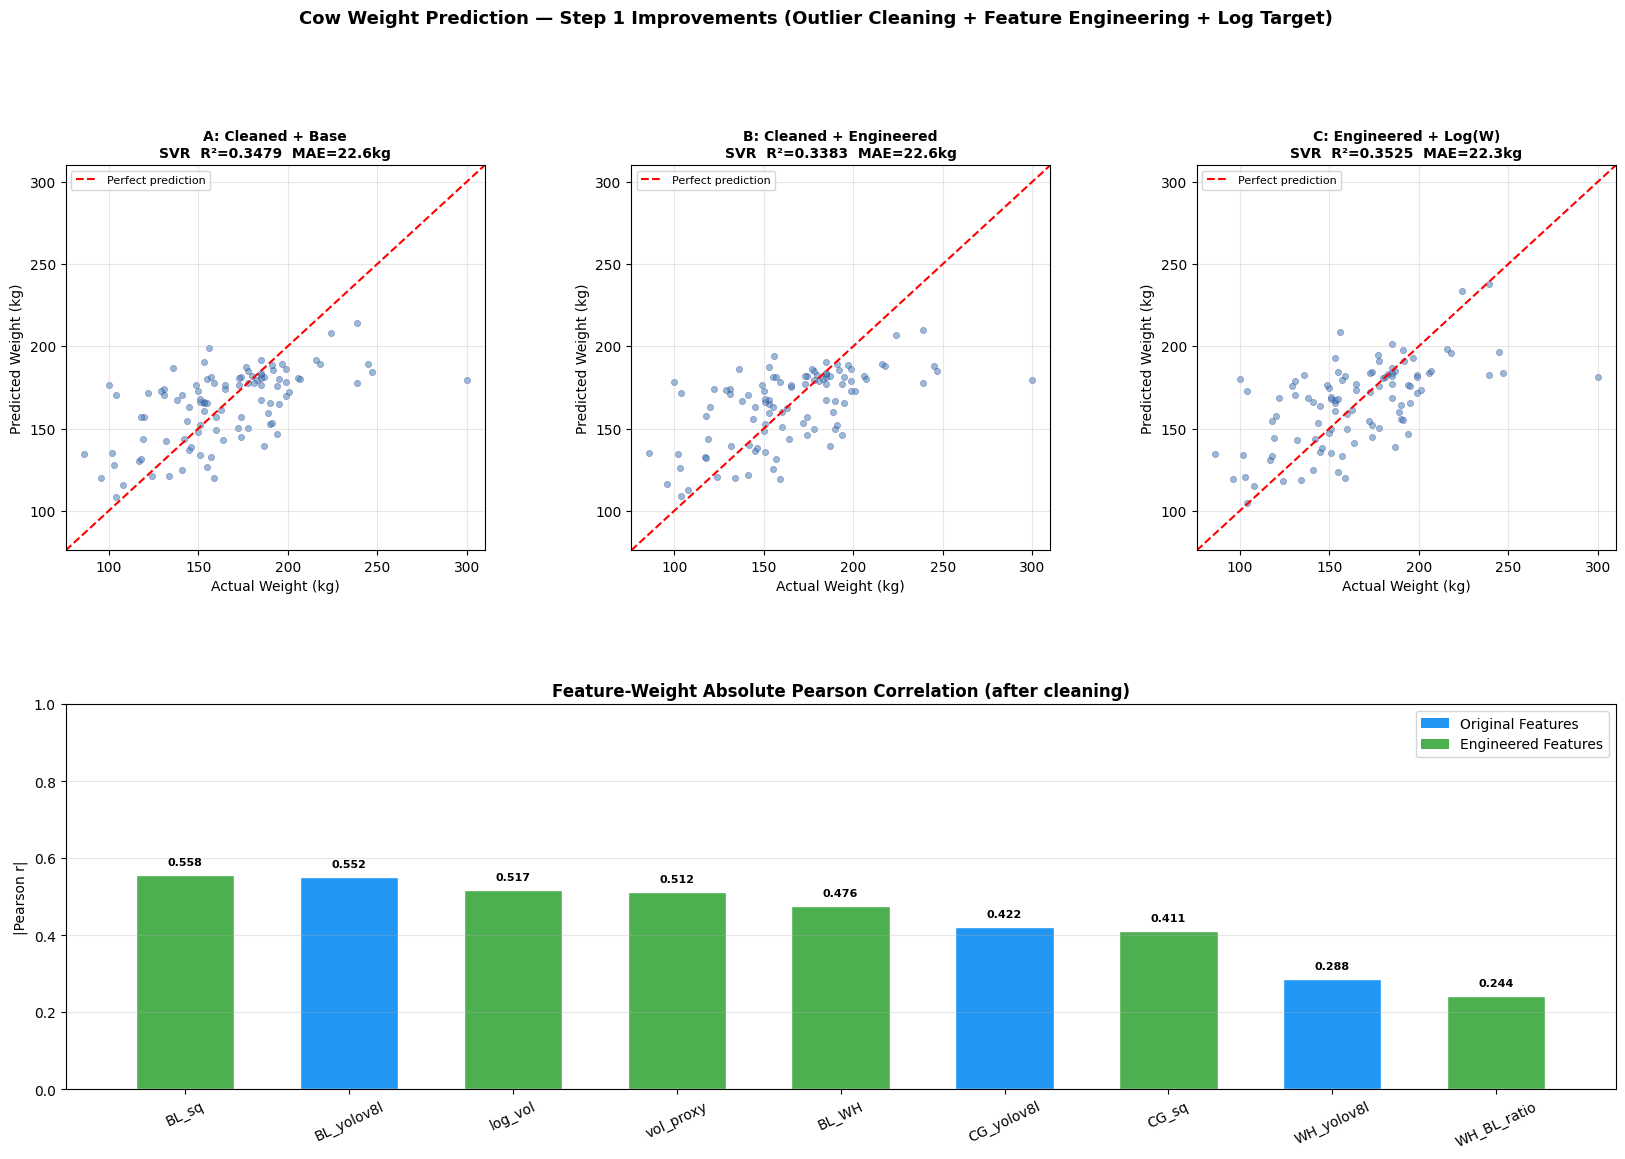

Visualization saved.


In [8]:
# === Visualise Best Model: SVR on Engineered Features ===
from sklearn.preprocessing import StandardScaler
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

scenarios = [
    ("A: Cleaned + Base",        X_base,       y_linear, res_A, False),
    ("B: Cleaned + Engineered",  X_engineered, y_linear, res_B, False),
    ("C: Engineered + Log(W)",   X_engineered, y_log,    res_C, True),
]

def get_best_svr_preds(X, y, log_target):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    if log_target:
        pipe = make_pipeline(StandardScaler(), SVR(C=0.1, epsilon=0.05))
    else:
        pipe = make_pipeline(StandardScaler(), SVR(C=10.0, epsilon=0.1))
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    if log_target:
        return np.exp(y_test), np.exp(preds)
    return y_test, preds

for col, (title, X, y, results, log_t) in enumerate(scenarios):
    ax = fig.add_subplot(gs[0, col])
    y_true_test, y_pred_test = get_best_svr_preds(X, y, log_t)
    lim = [min(y_true_test.min(), y_pred_test.min()) - 10,
           max(y_true_test.max(), y_pred_test.max()) + 10]
    ax.scatter(y_true_test, y_pred_test, alpha=0.55, s=20, color='steelblue', edgecolors='navy', lw=0.3)
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
    svr_res = next(r for r in results if 'SVR' in r['model_name'])
    ax.set_title(f"{title}\nSVR  R²={svr_res['test']['r2']:.4f}  MAE={svr_res['test']['mae']:.1f}kg",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual Weight (kg)'); ax.set_ylabel('Predicted Weight (kg)')
    ax.legend(fontsize=8); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.grid(True, alpha=0.3)

# Feature correlation bar chart
ax4 = fig.add_subplot(gs[1, :])
corrs = [(col, abs(stats.pearsonr(df_clean[col], df_clean['weight_kg'])[0]))
         for col in all_feat_cols]
corrs.sort(key=lambda x: x[1], reverse=True)
labels, vals = zip(*corrs)
colors = ['#2196F3' if l in feat_base else '#4CAF50' for l in labels]
bars = ax4.bar(labels, vals, color=colors, edgecolor='white', width=0.6)
ax4.set_title('Feature-Weight Absolute Pearson Correlation (after cleaning)', fontsize=12, fontweight='bold')
ax4.set_ylabel('|Pearson r|')
ax4.set_ylim(0, 1)
for bar, val in zip(bars, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', label='Original Features'),
                   Patch(facecolor='#4CAF50', label='Engineered Features')]
ax4.legend(handles=legend_elements, loc='upper right')
ax4.tick_params(axis='x', rotation=25)
ax4.grid(axis='y', alpha=0.3)

plt.suptitle('Cow Weight Prediction — Step 1 Improvements (Outlier Cleaning + Feature Engineering + Log Target)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'../datasets/acme_ai/tests/feature_extraction_result/step1_improvement_results.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Visualization saved.")
